In [1]:
%reload_ext autoreload
%autoreload 2

#load libraries
import glob
import os
import pandas as pd
from datetime import datetime
import numpy as np
import main_funcs as mfun

import plot_funcs as pfun
import utils_funcs as utils # utils is from Vape - catcher file: 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import pickle
import psychofit.psychofit as psy

# Get the data info
pfun.set_figure()


In [113]:
# repo_analysis_path = r'C:/Users/Huriye/Documents/code/sideBiasLateralisation/analysis'
# info = pickle.load(open(os.path.join(repo_analysis_path, 'sideBiasLateralisation_info2.pkl'), 'rb'))

# Get the list to extract the files for further analysis
animalList= ['MAT058']#,'MAT057','MAT058', 'MAT067', 'MAT068','MAT069']#] #
#'MAT038','MAT039', 'MAT045', 'MAT046','MAT066'
#,'HA011','HAT009','HAT010,'MBL015','MBL014',] n = 15
info = mfun.analysis(animalList=animalList)
info.recordingList = info.recordingList[
    (info.recordingList['performance'] > 50) &
    (info.recordingList['twoP']) &
    (info.recordingList['duration'] > 20)
    ].reset_index(drop=True)
info = mfun.update_info(info)
print('Total Session fits the selection: ' +  str(info.recordingList.shape[0]))

Env: decMaking
Computer: Huriye Windows
Total Session fits the selection: 26


In [116]:
selectedAnimal = animalList[0]

results = []  # collect summary rows

# make it per animal
for animal in info.recordingList.animalID.unique():
    print(f"Processing animal: {animal}")
    animal_sessions = info.recordingList[info.recordingList.animalID == animal]
    print(f"  Total sessions for {animal}: {len(animal_sessions)}")

# for each recording session, check if responsive neuron file exists in the analysis folder
for ind, recordingDate in enumerate(info.recordingList.recordingDate):
    if ind > -0: #(info.recordingList.sessionType[ind] =='SingleFullContrasts'): # TwoFullContrasts only look at single contrast sessions for now
      #  print(ind, info.recordingList.animalID[ind], info.recordingList.recordingDate[ind])
        pathname = info.recordingList.analysispathname[ind]
        sessionName = info.recordingList.sessionName[ind]

        # ---- load csv file ----
        filenameCSV = os.path.join(pathname, f"{sessionName}_CorrectedEventTimes.csv")
        if not os.path.exists(filenameCSV):
            print(f"[SKIP] Missing CSV: {filenameCSV}")
            continue

        df = pd.read_csv(filenameCSV)

        # ---- calculate response time ----
        # RT = choiceCompleteTime - choiceStartTime
        df["responseTime"] = mfun.compute_response_time(df)

        # ---- calculate the cut off trials in the session - exclude motivation loss trials ----
        end_trial_number, end_trial_row_index = mfun.find_motivation_cutoff_trial(df, rt_col="responseTime", factor=4.0)

        if end_trial_number is None:
            # if no cutoff detected, keep all trials
            df_motiv = df.copy()
            cutoff_note = "no_cutoff"
        else:
            # "give me that trial as the end trial"
            # Usually you exclude that trial and all after it as "unmotivated".
            # So keep trials strictly BEFORE the end_trial_row_index.
            df_motiv = df.iloc[:end_trial_row_index].copy()
            cutoff_note = f"cutoff_at_trial_{end_trial_number}"


        # ---- calculate the bias after removing unmotivated trials ----
        bias = mfun.compute_zero_stim_bias(df_motiv)

        # calculate mean P(right) for all left side rewarded trials (negative contrasts)
        df_motiv['choiceCorrect'] = df_motiv.apply(lambda row: 1 if row['correctResponse'] == row['choice'] else 0, axis=1)
        left_side_trials = df_motiv[df_motiv['contrastLeft'] > df_motiv['contrastRight']]
        # lets create one column of correct response 
        p_right_left_side = left_side_trials['choiceCorrect'].mean() if not left_side_trials.empty else np.nan

        right_side_trials = df_motiv[df_motiv['contrastLeft'] < df_motiv['contrastRight']]
        p_right_right_side = right_side_trials['choiceCorrect'].mean() if not right_side_trials.empty else np.nan

        info.recordingList.loc[ind, "p_right_left_side"] = p_right_left_side
        info.recordingList.loc[ind, "p_right_right_side"] = p_right_right_side
       # info.recordingList.loc[ind, "performance"] = df_motiv['choiceCorrect'] .mean()


        ##### plot psychometric curve
        pars, L, data, g = mfun.fit_psy_AllContrasts(df_motiv)
        #(fig, ax) = plt.subplots(figsize=(6, 5) )

        # lets plot the dat
        xx = data [0, :]
        nn = data [1, :]
        dd = data [2, :]
        plt.plot(xx, dd, 'ro')
        plt.plot(np.arange(-50, 50), psy.erf_psycho_2gammas( pars, np.arange(-50, 50) ), color = 'r')
        plt.plot((-50, 50), (.5, .5), 'k:')
        plt.xlim([-55, 55])
        plt.ylim([-0.05, 1.05])
        plt.xlabel('% contrast')
        plt.ylabel('proportion rightward')
        print(f"Session: {sessionName}, SessionType: {info.recordingList.sessionType[ind]}, Bias: {bias:.2f}, P(right|left side): {p_right_left_side:.2f}, P(right|right side): {p_right_right_side:.2f}")


        # xfit = np.arange(-50, 51)
        # pars_opt = np.array(pars, dtype=float).copy()
        # pars_opt[0] = 0.0        # bias = 0 (center at 0%)
        # pars_opt[1] = 10      # slope = 1
        # pars_opt[2:] = 0.0       # remove lapses (and any extra gamma params)

        # plt.plot(xfit, psy.erf_psycho_2gammas(pars_opt, xfit), 'k--', linewidth=2, label='Optimal')

        # plt.xlabel('% contrast')
        # plt.ylabel('Proportion rightward')
        # #plt.show()

        # # # save in analysis folder
        # plot_filename = os.path.join(info.figsPath, f"{sessionName}_All_psychometric_curve2.png")
        # plt.savefig(plot_filename)
        # plt.close()

        # lets add sams way of calculating side association
        side_assoc_metrics = mfun.sams_side_association(df_motiv)
        for key, value in side_assoc_metrics.items():
            info.recordingList.loc[ind, key] = value

        #lets add them as a new column to the info.recordingList 

        info.recordingList.loc[ind, "end_trial_number"] = end_trial_number if end_trial_number is not None else np.nan

        info.recordingList.loc[ind, "bias"] = bias
        info.recordingList.loc[ind, "biasPsycho_bias"] =  pars[0]
        info.recordingList.loc[ind, "biasPsycho_slope"] = pars[2]
        info.recordingList.loc[ind, "cutoff_note"] = cutoff_note

info.recordingList['imagingDataExtracted']=1

same_sign = ((info.recordingList['bias'] > 0) & (info.recordingList['p_right_right_side'] - info.recordingList['p_right_left_side'] > 0)) | \
            ((info.recordingList['bias'] < 0) & (info.recordingList['p_right_right_side'] - info.recordingList['p_right_left_side'] < 0))
info.recordingList['bias_sideassoc_same_sign'] = same_sign

# # # save in analysis folder
plot_filename = os.path.join(info.figsPath,  f"{selectedAnimal}_psychometric_curve_AllSessions.png")
plt.savefig(plot_filename)
plt.close()


Processing animal: MAT058
  Total sessions for MAT058: 26
Session: 2025-10-27_1_MAT058, SessionType: SingleFullContrasts, Bias: -0.23, P(right|left side): 0.92, P(right|right side): 0.82
Session: 2025-10-28_1_MAT058, SessionType: SingleFullContrasts, Bias: -0.35, P(right|left side): 0.99, P(right|right side): 0.55
Session: 2025-10-29_1_MAT058, SessionType: SingleFullContrasts, Bias: -0.19, P(right|left side): 0.93, P(right|right side): 0.69
Session: 2025-10-30_1_MAT058, SessionType: SingleFullContrasts, Bias: -0.45, P(right|left side): 0.99, P(right|right side): 0.35
Session: 2025-10-31_1_MAT058, SessionType: SingleFullContrasts, Bias: -0.26, P(right|left side): 0.96, P(right|right side): 0.41
Session: 2025-11-03_1_MAT058, SessionType: SingleFullContrasts, Bias: -0.06, P(right|left side): 0.89, P(right|right side): 0.64
Session: 2025-11-05_1_MAT058, SessionType: SingleFullContrasts, Bias: -0.39, P(right|left side): 0.95, P(right|right side): 0.54
Session: 2025-11-07_1_MAT058, SessionTy

Plot saved: C:\Users\Huriye\Documents\code\sideBiasLateralisation\figs\MAT058_bias_summary_TwoFullContrasts.png


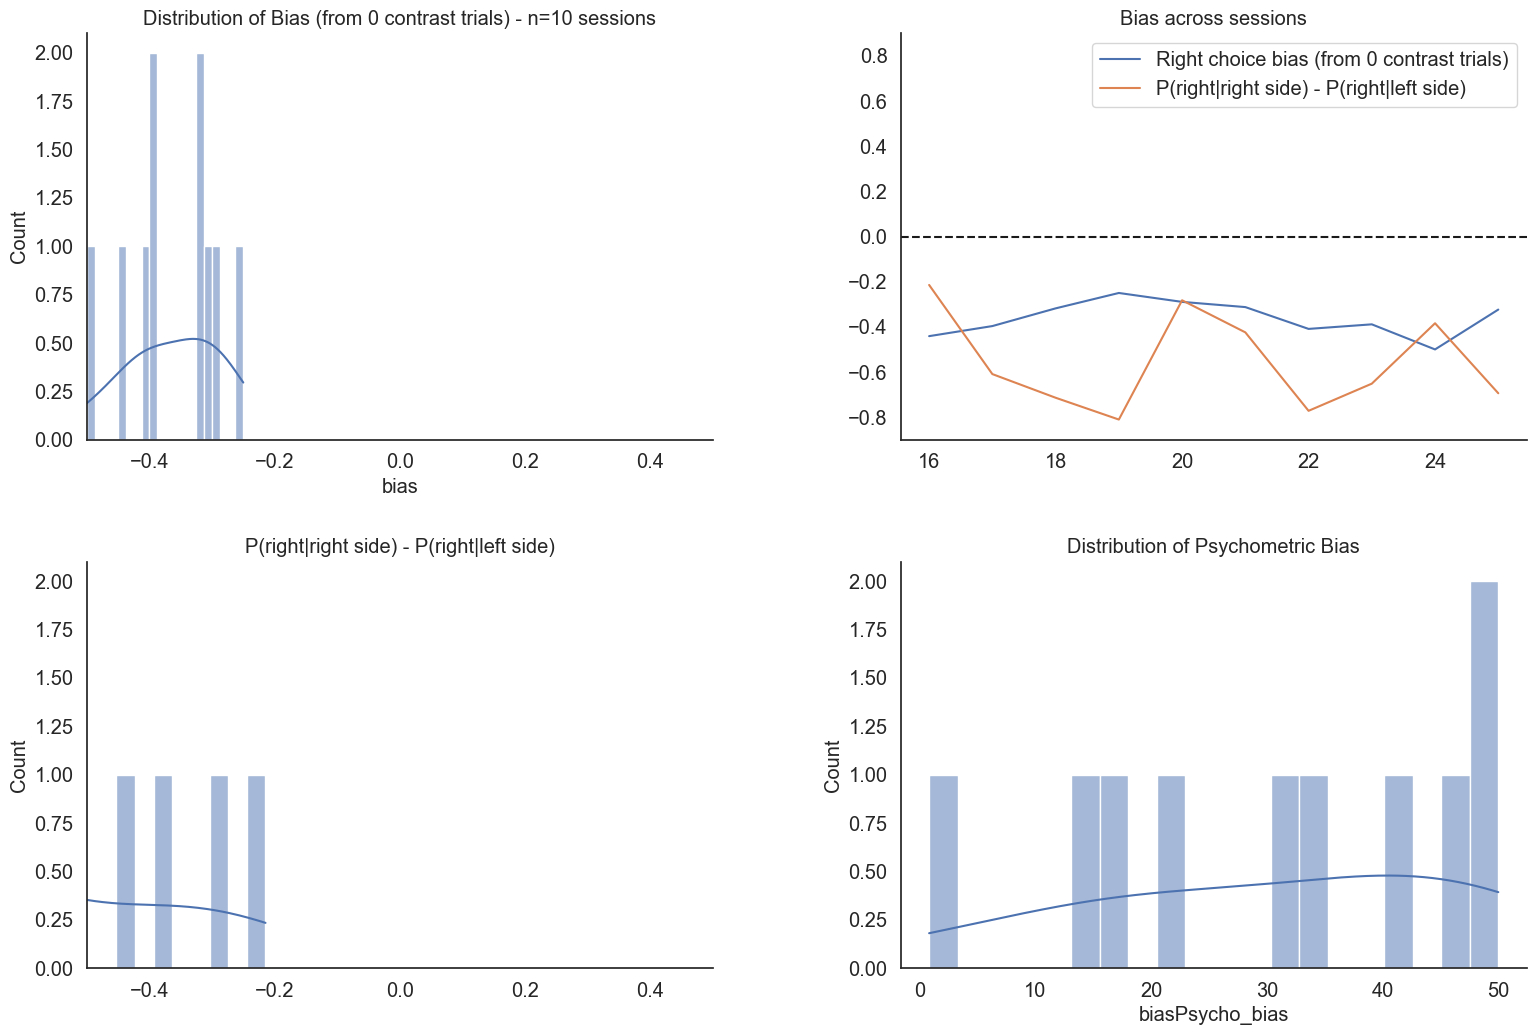

In [119]:
sessionType = 'TwoFullContrasts'
# lets explore bias for each animal 
recordingListSelected = info.recordingList[(info.recordingList['sessionType']== sessionType) & (info.recordingList['animalID']== selectedAnimal)]

pfun.set_figure()
fig = plt.figure(constrained_layout=False, figsize=(16, 11)) # 8,11 for full A4 page

gs_contrast  = fig.add_gridspec(ncols=2, nrows=2, bottom=0.05, top=0.9, left=0.05, right=0.95,
                              wspace=0.3, hspace=0.3)
ax_contrast = {xx: fig.add_subplot(gs_contrast[xx]) for xx in range(4)}


ax_contrast[1].plot(recordingListSelected['bias'], label='Right choice bias (from 0 contrast trials)')
ax_contrast[1].plot(recordingListSelected['p_right_right_side']-recordingListSelected['p_right_left_side'], label='P(right|right side) - P(right|left side)') 
ax_contrast[1].set_title('Bias across sessions')
#add a line at y =0
ax_contrast[1].axhline(0, color='k', linestyle='--')
ax_contrast[1].set_ylim([-0.9, 0.9]) 
ax_contrast[1].legend()

sns.histplot(recordingListSelected['bias'], bins=20, kde=True, ax=ax_contrast[0])
# add total number of sessions in the title
ax_contrast[0].set_title(f'Distribution of Bias (from 0 contrast trials) - n={recordingListSelected.shape[0]} sessions')
ax_contrast[0].set_xlim([-0.5, 0.5])  

sns.histplot(recordingListSelected['p_right_right_side']-recordingListSelected['p_right_left_side'], bins=20, kde=True, ax=ax_contrast[2])
ax_contrast[2].set_title('P(right|right side) - P(right|left side)')
ax_contrast[2].set_xlim([-0.5, 0.5])

sns.histplot(recordingListSelected['biasPsycho_bias'], bins=20, kde=True, ax=ax_contrast[3])
ax_contrast[3].set_title('Distribution of Psychometric Bias')
#ax_contrast[3].set_xlim([-10, 1])

# save with animal ID
plot_filename = os.path.join(info.figsPath, f"{selectedAnimal}_bias_summary_{sessionType}.png")
plt.savefig(plot_filename)
#plt.close()

print('Plot saved: ' + plot_filename)


In [123]:
sessionType = 'TwoFullContrasts'
recordingListSelected = info.recordingList[(info.recordingList['sessionType']==sessionType)
                                            & (info.recordingList['animalID']== selectedAnimal)].reset_index(drop=True)

saveFileName = os.path.join(info.figsPath, f"{selectedAnimal}_psychometric_{sessionType}.png")

pfun.plot_combined_psychometric(
    recordingList= recordingListSelected,
    save_fileName= saveFileName,
)

[np.float64(-0.5), np.float64(-0.375), np.float64(-0.25), np.float64(-0.125), np.float64(0.0), np.float64(0.125), np.float64(0.25), np.float64(0.375), np.float64(0.5)]
Figure saved at: C:\Users\Huriye\Documents\code\sideBiasLateralisation\figs\MAT058_psychometric_TwoFullContrasts.png


Number of sessions with positive bias and positive P(right) difference: 23


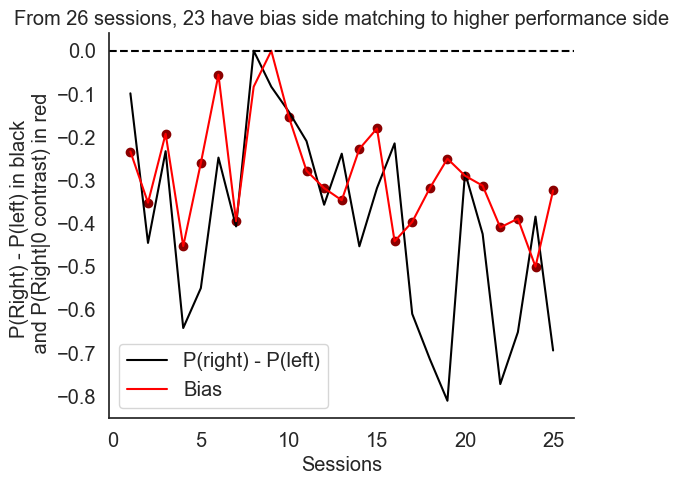

In [125]:
# lets get the number of sessions
fig, ax = plt.subplots(figsize=(6, 5))
plt.plot(info.recordingList['p_right_right_side']-info. recordingList['p_right_left_side'], color='black')
plt.plot(info.recordingList['bias'], color='red')
plt.xlabel('Sessions')
plt.ylabel('P(Right) - P(left) in black \n and P(Right|0 contrast) in red')
plt.legend(['P(right) - P(left)', 'Bias'])
# add a line at y=0
plt.axhline(0, color='black', linestyle='--')

# add a dot if bias & P(right) - P(left) have same sign
# same_sign = ((info.recordingList['bias'] > 0) & (info.recordingList['p_right_right_side'] - info.recordingList['p_right_left_side'] > 0)) | \
#             ((info.recordingList['bias'] < 0) & (info.recordingList['p_right_right_side'] - info.recordingList['p_right_left_side'] < 0))

# lets 

plt.scatter(np.where(same_sign)[0], info.recordingList['bias'][same_sign], color='darkred', label='Same sign')
#add title - total number of same side
plt.title(f'From {len(info.recordingList)} sessions, {same_sign.sum()} have bias side matching to higher performance side')

# how many of them bias is positive & p_right_right_side - p_right_left_side is positive
positive_bias_count = ((info.recordingList['bias'] < 0) & (info.recordingList['p_right_right_side'] - info.recordingList['p_right_left_side'] < 0)).sum()
print(f'Number of sessions with positive bias and positive P(right) difference: {positive_bias_count}')

# save the file
plot_filename = os.path.join(info.figsPath, f"{selectedAnimal}_dayByday_bias_vs_sideassoc_{sessionType}.png")
plt.savefig(plot_filename)

Number of sessions with bias >=0.25: 0
Number of sessions with bias <=-0.25: 22


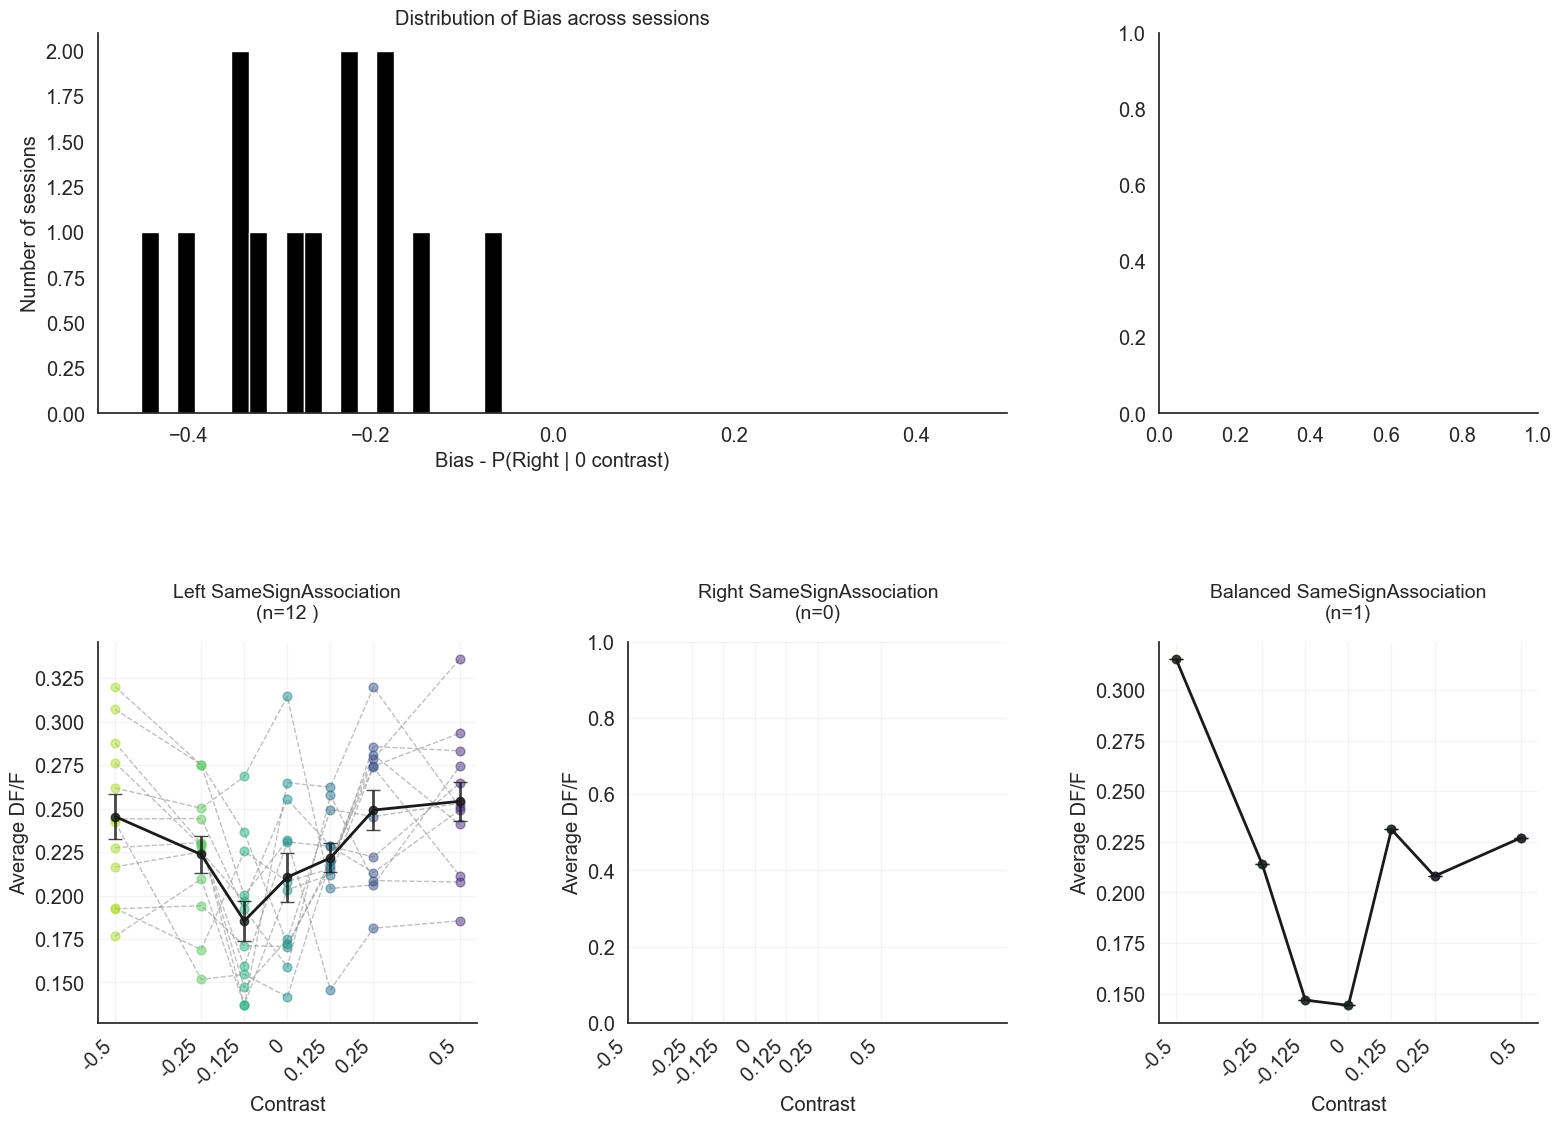

In [ ]:
#get info for below 0.25 bias sessions
pfun.set_figure()
fig = plt.figure(constrained_layout=False, figsize=(16, 11)) # 8,11 for full A4 page

gs_contrast  = fig.add_gridspec(ncols=3, nrows=2, bottom=0, top=0.9, left=0.05, right=0.95,
                              wspace=0.4, hspace=0.6)
ax_contrast = {xx: fig.add_subplot(gs_contrast[xx]) for xx in range(6)}

#### Parameters
sessionType = 'SingleFullContrasts'
biasType = 'bias'
bias_sideassoc_same_signValue = True
response_typeValue = 'excited' # 'excited', 'inhibited', 'all'
if bias_sideassoc_same_signValue:
    subtitle_suffix = 'SameSignAssociation'
else:
    subtitle_suffix = 'OppositeSignAssociation'
leftThreshold = -0.1
rightThreshold = 0.1
performanceCutOff = 0


###### Plot the histogram for bias
ax_contrast[0].remove()                       # remove old axis in slot 0
ax_contrast[1].remove()                       # remove old axis in slot 0
ax_contrast[0] = fig.add_subplot(gs_contrast[0, 0:2])  # span first two slots
ax_contrast[0].hist(info.recordingList[biasType]
                    [(info.recordingList['bias_sideassoc_same_sign']== bias_sideassoc_same_signValue) &
                     (info.recordingList['sessionType'] == sessionType)].dropna(),
                    bins=20, color = 'black')
ax_contrast[0].set_ylabel('Number of sessions')
ax_contrast[0].set_xlabel('Bias - P(Right | 0 contrast)')
ax_contrast[0].set_title('Distribution of Bias across sessions')
#ax_contrast[0].set_xlim([-50, 50])
ax_contrast[0].set_xlim([-0.5, 0.5])
#ax_contrast[0].set_xticks([-0.5, -0.25, 0, 0.25, 0.5])

# get the total number of recording for 0.75 above + 0.25 below
num_high_bias = len(info.recordingList[info.recordingList[biasType] >= rightThreshold])
num_low_bias = len(info.recordingList[info.recordingList[biasType] <= leftThreshold])
print(f'Number of sessions with bias >=0.25: {num_high_bias}')  
print(f'Number of sessions with bias <=-0.25: {num_low_bias}')

# Plot the mean dF/F by contrast for low bias sessions - LEFT BIAS
t2 = 1
peformanceCutOff = 0

infoSelected = info.recordingList[(info.recordingList[biasType] < leftThreshold) & 
                                (info.recordingList['bias_sideassoc_same_sign']== bias_sideassoc_same_signValue) &
                                (info.recordingList['sessionType'] == sessionType) &
                                (info.recordingList['performance'] >performanceCutOff)].reset_index(drop=True)
# how many sessions
nSes = infoSelected.shape
pfun.plot_mean_dff_by_contrast( # Average
    recordingList = infoSelected,
    event_type='stimulus',
    time_window=[0, t2],
    subfolder='all_neurons',
    response_type = response_typeValue,
    save_path=info.figsPath,
    contrasts_rewarded=['-0.5 Rewarded','-0.25 Rewarded','-0.125 Rewarded'  , '0 Rewarded', '0.125 Rewarded', '0.25 Rewarded', '0.5 Rewarded'], 
    contrast_values=[ -0.5, -0.25, -0.125, 0, 0.125, 0.25, 0.5],
    axis = ax_contrast[3],
    title = 'Left ' + subtitle_suffix + '\n(n=' + str(nSes[0]) +' )',
)

# Plot the mean dF/F by contrast for low bias sessions - RIGHT BIAS

infoSelected = info.recordingList[(info.recordingList[biasType] > rightThreshold) &
                                   (info.recordingList['bias_sideassoc_same_sign']== bias_sideassoc_same_signValue) &
                                   (info.recordingList['sessionType'] == sessionType) &
                                   (info.recordingList['performance'] >performanceCutOff)].reset_index(drop=True)
# how many sessions
nSes = infoSelected.shape
pfun.plot_mean_dff_by_contrast( # Average
    recordingList = infoSelected,
    event_type='stimulus',
    time_window=[0, t2],
    subfolder='all_neurons',
    response_type = response_typeValue,
    save_path=info.figsPath,
    contrasts_rewarded=['-0.5 Rewarded','-0.25 Rewarded','-0.125 Rewarded'  , '0 Rewarded', '0.125 Rewarded', '0.25 Rewarded', '0.5 Rewarded'], 
    contrast_values=[ -0.5, -0.25, -0.125, 0, 0.125, 0.25, 0.5],
    axis = ax_contrast[4],
    title = 'Right ' + subtitle_suffix + '\n(n=' + str(nSes[0]) +')',
)


# Plot the mean dF/F by contrast for low bias sessions - LEFT BIAS

infoSelected = info.recordingList[(info.recordingList[biasType] <= rightThreshold) &
                                (info.recordingList[biasType] >= leftThreshold) & 
                                  (info.recordingList['bias_sideassoc_same_sign']== bias_sideassoc_same_signValue) &
                                  (info.recordingList['sessionType'] == sessionType) &
                                  (info.recordingList['performance'] >performanceCutOff)].reset_index(drop=True)


# how many sessions
nSes = infoSelected.shape
pfun.plot_mean_dff_by_contrast( # Average
    recordingList = infoSelected,
    event_type='stimulus',
    time_window=[0, t2],
    subfolder='all_neurons',
    response_type = response_typeValue,
    save_path=info.figsPath,
    contrasts_rewarded=['-0.5 Rewarded','-0.25 Rewarded','-0.125 Rewarded'  , '0 Rewarded', '0.125 Rewarded', '0.25 Rewarded', '0.5 Rewarded'], 
    contrast_values=[ -0.5, -0.25, -0.125, 0, 0.125, 0.25, 0.5],
    axis = ax_contrast[5],
    title = 'Balanced ' + subtitle_suffix + '\n(n=' + str(nSes[0]) +')',
)

pfun.save_figure(f'{selectedAnimal}_{response_typeValue}_{biasType}_AssociationSide{bias_sideassoc_same_signValue}_{sessionType}', info.figsPath)



In [127]:
df_cdiff = mfun.get_mean_dff_by_contrast_diff_df(info.recordingList[ (info.recordingList['bias_sideassoc_same_sign']== False)].reset_index(drop=True), event_type="stimulus", biasType=biasType)

df = df_cdiff.copy()
df["side"] = np.where(
    df["cDiff"] > 0, "Right",
    np.where(df["cDiff"] < 0, "Left", None)  # <-- None, not np.nan
)

out = (
    df.groupby(["animal", "session", "recordingDate",'bias', 'performance',"side"], as_index=False)
      .agg(mean_dff=("mean_dff", "mean"))
      .pivot_table(
          index=["animal", "session", "recordingDate", 'bias', 'performance'],
          columns="side",
          values="mean_dff",
      )
      .reset_index()
)

df = out.copy()
df['cDiff'] = df['Right'] - df['Left']

pfun.set_figure()
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=df, x='bias', y='cDiff', ax=ax, color='black')
ax.set_xlabel('Behavioral Bias \n(Proportion of Right choices at 0 contrast)')
ax.set_ylabel('Neural Lateralisation \n(Mean dF/F Right - Mean dF/F Left)')
# add stats & line
from scipy.stats import pearsonr
r, p = pearsonr(df['bias'], df['cDiff'])
#sns.regplot(data=df, x='bias', y='cDiff', ax=ax, scatter=False, color='red', line_kws={'linewidth':1})
ax.set_title(f'Correlation \n r={r:.2f}, p={p:.3f}')
pfun.save_figure(f'Phase4_DifferentSide_BehavioralBias_vs_NeuralLateralisation', info.figsPath)

# add only really good performance
df_highperf = df[df['performance'] >=0.85]
sns.scatterplot(data=df_highperf, x='bias', y='cDiff', ax=ax, color='darkred')
r2, p2 = pearsonr(df_highperf['bias'], df_highperf['cDiff'])
ax.set_title(f'Correlation \n r={r:.2f}, p={p:.3f}' + f'\n High Performance: r={r2:.2f}, p={p2:.3f}')
pfun.save_figure(f'Phase4_DifferentSide_BehavioralBias_vs_NeuralLateralisation_highPerf', info.figsPath)


KeyError: 'cDiff'

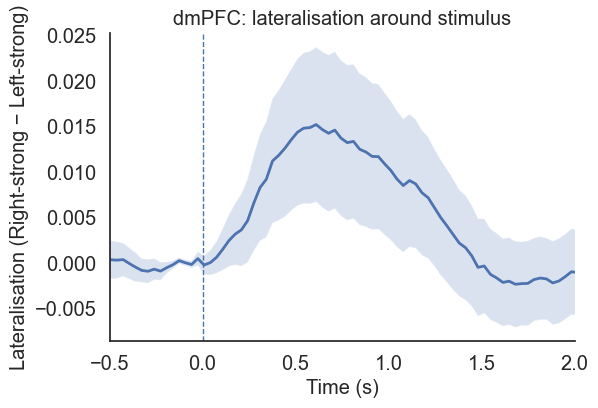

In [143]:
# -----------------------------
# Example usage
# -----------------------------
df_lat, t = mfun.compute_time_resolved_lateralisation(
    info.recordingList,
    event_type="stimulus",
    subfolder="responsive_neurons",
    use_zscored=True,
    pos_cdiffs=(0.125, 0.25, 0.5),
    neg_cdiffs=(-0.125, -0.25, -0.5),
    baseline_window=(-0.2, 0.0)
)
mfun.plot_time_resolved_lateralisation(df_lat, t, title="dmPFC: lateralisation around stimulus", xlim=(-0.5, 2.0))

# # If you want per-session traces (for correlation with Δslope):
# # df_lat has one row per session, lat_trace is the full timecourse.
# # You can also compute a scalar “pre-choice lateralisation” by averaging a window:
# # df_lat["lat_prechoice"] = df_lat["lat_trace"].apply(lambda x: np.nanmean(x[(t>=0.1) & (t<=0.5)]))


# save the plot
pfun.save_figure(f'TimeResolvedLateralisation_dmPFC', info.figsPath)


In [158]:
df_lat_pc.head()

,animalID,sessionName,recordingDate,event_type,n_pos_conditions,n_neg_conditions,pos_mean_trace,neg_mean_trace,lat_trace,lat_prechoice
0,HA011,2025-08-31_1_HA011,2025-08-31,stimulus,9,9,"[0.0010231924, 0.0035774303, 0.0017149262, -1....","[-0.022253485, -0.02188445, -0.024056338, -0.0...","[0.023276677, 0.02546188, 0.025771264, 0.02337...",0.023117
1,HA011,2025-09-02_1_HA011,2025-09-02,stimulus,9,6,"[0.025062835, 0.017000219, 0.014375395, 0.0110...","[0.021875622, 0.02093672, 0.01936493, 0.018682...","[0.003187213, -0.003936501, -0.0049895355, -0....",-0.037251
2,HA011,2025-09-03_1_HA011,2025-09-03,stimulus,9,8,"[-0.02827346, -0.027178165, -0.024321398, -0.0...","[-0.0045788656, -0.005710719, -0.008537513, -0...","[-0.023694593, -0.021467445, -0.015783884, -0....",0.026245
3,HA011,2025-09-04_1_HA011,2025-09-04,stimulus,9,9,"[0.023796953, 0.025118891, 0.024639435, 0.0236...","[0.025250448, 0.025437845, 0.022878356, 0.0200...","[-0.0014534947, -0.00031895377, 0.0017610788, ...",-0.062746
4,HA011,2025-09-07_1_HA011,2025-09-07,stimulus,9,8,"[0.007837643, 0.0034595612, 0.0003863391, 0.00...","[0.023407696, 0.015571166, 0.01752437, 0.02302...","[-0.015570053, -0.012111604, -0.017138032, -0....",-0.001311


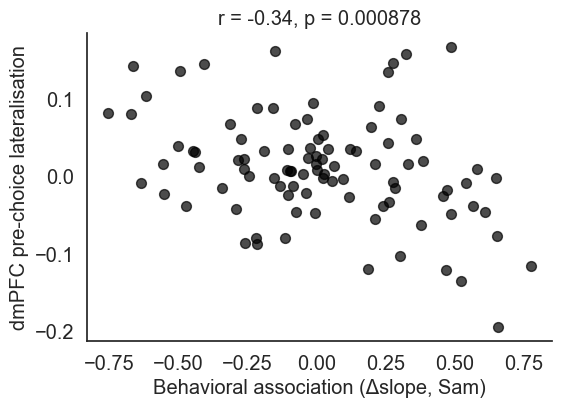

In [156]:
df_lat_pc = mfun.extract_prechoice_lat(df_lat, t, win=(0.2, 0.8))
df_merge = pd.merge(
    df_lat_pc,
    info.recordingList,
    on=["animalID", "sessionName"],
    how="inner"
)

x = df_merge["R_minus_L_slope"].to_numpy()
y = df_merge["lat_prechoice"].to_numpy()

r, p = pearsonr(x, y)

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=50, c='black', alpha=0.7)
#plt.axhline(0, color="k", lw=1)
#plt.axvline(0, color="k", lw=1)

m, b = np.polyfit(x, y, 1)
xx = np.linspace(np.min(x), np.max(x), 100)
#plt.plot(xx, m*xx + b, 'r')

plt.xlabel("Behavioral association (Δslope, Sam)")
plt.ylabel("dmPFC pre-choice lateralisation")
plt.title(f"r = {r:.2f}, p = {p:.3g}")

#save
pfun.save_figure(f'PrechoiceLateralisation_vs_BehavioralAssociation', info.figsPath)

In [ ]:
# Plot combined psychometric
pfun.plot_combined_psychometric(
    info=info,
    save_path=None  # Will use default path if None
)

# Plot combined response time
pfun.plot_combined_response_time(
    info=info,
    analysis_path=analysis_path,
    save_path=None  # Will use default path if None
)

In [ ]:
# plot neural activity across sessions
# analysis_params = ['ipsi_recside', 'contra_recside']
analysis_params = ['ipsi_bias', 'contra_bias']
# Only responsive neurons, z-scored data
pfun.plot_combined_neural_activity(info, analysis_params, duration=[3], zscoreRun=True, use_responsive_only=True)

# All neurons, z-scored data
pfun.plot_combined_neural_activity(info, analysis_params, duration=[3], zscoreRun=True, use_responsive_only=False)

In [ ]:
# Plot combined dff mean by contrast
use_responsive_only = True  # Change to False to use all neurons
zscoreRun = True  # Change to False to use raw data

# Call the function
pfun.plot_combined_dff_mean_by_contrast(
    info=info,
    zscoreRun=zscoreRun,
    use_responsive_only=use_responsive_only,
    save_path=None  # Will use default path if None
)